# Experiments

Dieses Notebook enth?lt die systematische Fidelity/Sparsity-Evaluation f?r GNNExplainer und Integrated Gradients.

- Fidelity wird getrennt f?r `H` und `C` aggregiert.
- Standardm??ig wird nur der **erste Graph pro `compound`** im gew?hlten Scope verwendet.
- Scope kann zwischen `test_split` und `full_dataset` umgeschaltet werden.


In [3]:
import sys
from pathlib import Path

import ipywidgets as widgets
from IPython.display import display, clear_output


def _resolve_project_root() -> Path:
    cwd = Path.cwd()
    candidates = [
        cwd,
        cwd.parent,
        cwd / "gnn4nmr",
        cwd.parent / "gnn4nmr",
    ]
    for candidate in candidates:
        if (candidate / "scripts").exists() and (candidate / "notebooks").exists():
            return candidate
    raise RuntimeError(
        f"Could not resolve project root from cwd={cwd}. Expected a folder containing scripts/ and notebooks/."
    )


PROJECT_ROOT = _resolve_project_root()
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"
SCRIPTS_DIR = PROJECT_ROOT / "scripts"
DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"

for path in [str(PROJECT_ROOT), str(SCRIPTS_DIR)]:
    if path not in sys.path:
        sys.path.insert(0, path)

print(f"cwd: {Path.cwd()}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Notebook dir: {NOTEBOOK_DIR}")
print(f"Data dir: {DATA_DIR}")
print(f"Models dir: {MODELS_DIR}")


cwd: c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\notebooks
Project root: c:\Uni\Lab\gnn4nmr-lab\gnn4nmr
Notebook dir: c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\notebooks
Data dir: c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\data
Models dir: c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\models


In [4]:
from pathlib import Path

import ipywidgets as widgets
from IPython.display import display

# Make this cell runnable on its own (even after kernel restart)
if "NOTEBOOK_DIR" not in globals():
    NOTEBOOK_DIR = Path.cwd()
if "PROJECT_ROOT" not in globals():
    PROJECT_ROOT = NOTEBOOK_DIR.parent
if "MODELS_DIR" not in globals():
    MODELS_DIR = PROJECT_ROOT / "models"
if "DATA_DIR" not in globals():
    DATA_DIR = PROJECT_ROOT / "data"


def _list_files(directory: Path, extension: str):
    if directory.exists():
        return sorted([f.name for f in directory.glob(f"*{extension}")])
    return []


model_files = _list_files(MODELS_DIR, ".pt")
data_files = _list_files(DATA_DIR, ".pkl")

exp_model_widget = widgets.Dropdown(
    options=model_files if model_files else ["Keine Modelle gefunden"],
    description="Modell:",
    style={"description_width": "initial"},
)

exp_data_widget = widgets.Dropdown(
    options=data_files if data_files else ["Keine Daten gefunden"],
    description="Daten:",
    style={"description_width": "initial"},
)

split_file_widget = widgets.Text(
    value="models/graph_split.pkl",
    description="Split Datei:",
    style={"description_width": "initial"},
)

graph_scope_widget = widgets.Dropdown(
    options=[("Testsplit", "test_split"), ("Gesamtdatensatz", "full_dataset")],
    value="test_split",
    description="Graph Scope:",
    style={"description_width": "initial"},
)

first_graph_per_component_widget = widgets.Checkbox(
    value=True,
    description="Erster Graph pro Compound",
    indent=False,
)

component_key_widget = widgets.Text(
    value="compound",
    description="Component Key:",
    style={"description_width": "initial"},
)

node_types_widget = widgets.SelectMultiple(
    options=["H", "C", "Others"],
    value=("H", "C"),
    description="Node Types:",
    style={"description_width": "initial"},
)

sparsity_widget = widgets.FloatSlider(
    value=0.90,
    min=0.50,
    max=0.99,
    step=0.01,
    description="Sparsity:",
    style={"description_width": "initial"},
    readout_format=".2f",
)

mask_baseline_widget = widgets.Dropdown(
    options=["match_ig_baseline", "zero", "mean"],
    value="match_ig_baseline",
    description="Mask Baseline:",
    style={"description_width": "initial"},
)

ig_baseline_widget = widgets.Dropdown(
    options=["scientific", "zero", "mean", "random", "min", "max"],
    value="scientific",
    description="IG Baseline:",
    style={"description_width": "initial"},
)

gnn_epochs_widget = widgets.IntSlider(
    value=200,
    min=50,
    max=500,
    step=50,
    description="GNN Epochs:",
    style={"description_width": "initial"},
)

gnn_lr_widget = widgets.FloatLogSlider(
    value=0.01,
    base=10,
    min=-4,
    max=-1,
    step=0.1,
    description="GNN LR:",
    style={"description_width": "initial"},
    readout_format=".4f",
)

gnn_explanation_type_widget = widgets.Dropdown(
    options=["phenomenon", "model"],
    value="phenomenon",
    description="GNN Type:",
    style={"description_width": "initial"},
)

ig_n_steps_widget = widgets.IntSlider(
    value=64,
    min=8,
    max=256,
    step=8,
    description="IG Steps:",
    style={"description_width": "initial"},
)

max_graphs_widget = widgets.IntText(
    value=0,
    description="Max Graphen (0=all):",
    style={"description_width": "initial"},
)

max_nodes_per_graph_widget = widgets.IntText(
    value=0,
    description="Max Nodes/Graph (0=all):",
    style={"description_width": "initial"},
)

include_edge_report_widget = widgets.Checkbox(
    value=True,
    description="GNN Edge Report",
    indent=False,
)

seed_widget = widgets.IntText(
    value=0,
    description="Seed:",
    style={"description_width": "initial"},
)

output_dir_widget = widgets.Text(
    value="results/experiments",
    description="Output Dir:",
    style={"description_width": "initial"},
)

controls = widgets.VBox(
    [
        widgets.HBox([exp_model_widget, exp_data_widget]),
        widgets.HBox([split_file_widget, graph_scope_widget]),
        widgets.HBox([first_graph_per_component_widget, component_key_widget]),
        widgets.HBox([node_types_widget, sparsity_widget]),
        widgets.HBox([mask_baseline_widget, ig_baseline_widget]),
        widgets.HBox([gnn_epochs_widget, gnn_lr_widget, gnn_explanation_type_widget]),
        widgets.HBox([ig_n_steps_widget, max_graphs_widget, max_nodes_per_graph_widget]),
        widgets.HBox([include_edge_report_widget, seed_widget, output_dir_widget]),
    ]
)

display(controls)


## Fidelity and Sparsity Metrics (Node-Level Regression)

Fuer jeden Knoten und jede Methode wird bei Ziel-Sparsity `s=0.90` zunaechst `k = max(1, ceil((1-s) * d))` (mit `d` = Feature-Anzahl) bestimmt.

- `S`: Top-k Features nach `|importance|`
- `actual_sparsity_feat = 1 - k/d`

Feature-Perturbationen am ausgewaehlten Knoten:

- `x_drop`: Features in `S` werden durch Baseline ersetzt
- `x_keep`: nur Features in `S` bleiben, Rest wird durch Baseline ersetzt

Mit `y_orig`, `y_drop`, `y_keep` und optional `y_true`:

- `fid_plus_model = |y_orig - y_drop|`
- `fid_minus_model = |y_orig - y_keep|`
- `fid_plus_error_delta = |y_drop - y_true| - |y_orig - y_true|`
- `fid_minus_error_delta = |y_keep - y_true| - |y_orig - y_true|`

Fuer den optionalen GNN-Edge-Report wird die Edge-Selektion global auf dem gesamten erklaerten Graphen durchgefuehrt:

- `E`: Anzahl aller beruecksichtigten Edges im Graphen
- `k_edge = max(1, ceil((1-s) * E))`, Ranking nach `|edge_mask|`
- Edge-`fid+`: Top-k Edges werden entfernt (`drop_selected`)
- Edge-`fid-`: Es bleiben nur die Top-k Edges erhalten (`keep_selected`)
- `actual_sparsity_edge = 1 - k_edge/E`

Die Aggregation erfolgt getrennt fuer `H` und `C`. Der faire Methodenvergleich nutzt nur die gemeinsame Node-Menge von GNNExplainer und IG.



In [5]:
from scripts.explainer.experiments_evaluation import (
    exp_load_eval_graph_indices,
    exp_build_mask_baseline,
    exp_topk_indices_from_importance,
    exp_predict_single_node,
    exp_feature_fidelity_for_node,
    exp_gnn_edge_fidelity_for_node,
    exp_extract_gnn_feature_importance,
    exp_extract_ig_feature_importance,
    select_scope_graph_indices,
    first_graph_indices_per_component,
    build_default_context,
    run_experiments_evaluation as _run_experiments_evaluation_core,
    run_fidelity_grid_evaluation as _run_fidelity_grid_evaluation_core,
    run_fidelity_grid_smoke_test as _run_fidelity_grid_smoke_test_core,
)


def run_experiments_evaluation(
    model_file=None,
    data_file=None,
    split_file=None,
    node_types=('H', 'C'),
    sparsity=0.90,
    mask_baseline_mode='match_ig_baseline',
    ig_baseline_mode='scientific',
    gnn_epochs=200,
    gnn_lr=0.01,
    gnn_explanation_type='phenomenon',
    ig_n_steps=64,
    graph_scope='test_split',
    first_graph_per_component=True,
    component_key='compound',
    max_graphs=None,
    max_nodes_per_graph=0,
    include_gnn_edge_report=True,
    output_dir='results/experiments',
    seed=0,
    verbose=True,
):
    model_name = model_file if model_file is not None else exp_model_widget.value
    data_name = data_file if data_file is not None else exp_data_widget.value

    if str(model_name).startswith('Keine') or str(data_name).startswith('Keine'):
        raise ValueError('Bitte g?ltige Modell- und Datendatei ausw?hlen.')

    split_eff = split_file if split_file is not None else split_file_widget.value

    context = build_default_context(
        project_root=PROJECT_ROOT,
        model_file=str(model_name),
        data_file=str(data_name),
        split_file=str(split_eff),
        output_dir=output_dir,
    )

    return _run_experiments_evaluation_core(
        context=context,
        node_types=node_types,
        sparsity=float(sparsity),
        mask_baseline_mode=str(mask_baseline_mode),
        ig_baseline_mode=str(ig_baseline_mode),
        gnn_epochs=int(gnn_epochs),
        gnn_lr=float(gnn_lr),
        gnn_explanation_type=str(gnn_explanation_type),
        gnn_use_custom_coeffs=False,
        gnn_coeffs=None,
        ig_n_steps=int(ig_n_steps),
        graph_scope=str(graph_scope),
        first_graph_per_component=bool(first_graph_per_component),
        component_key=str(component_key),
        max_graphs=max_graphs,
        max_nodes_per_graph=int(max_nodes_per_graph),
        include_gnn_edge_report=bool(include_gnn_edge_report),
        seed=int(seed),
        verbose=bool(verbose),
    )


def run_fidelity_grid_evaluation(
    model_file=None,
    data_file=None,
    split_file=None,
    node_types=('H', 'C'),
    sparsities=(0.5, 0.6, 0.7, 0.8, 0.9),
    mask_variants=('zero', 'scientific'),
    gnn_epochs=200,
    gnn_lr=0.01,
    gnn_explanation_type='phenomenon',
    ig_n_steps=64,
    max_graphs=None,
    max_nodes_per_graph=0,
    include_gnn_edge_report=True,
    output_dir='results/experiments',
    seed=0,
    verbose=True,
    progress_enabled=True,
    progress_use_tqdm=True,
    run_name=None,
):
    model_name = model_file if model_file is not None else exp_model_widget.value
    data_name = data_file if data_file is not None else exp_data_widget.value
    if str(model_name).startswith('Keine') or str(data_name).startswith('Keine'):
        raise ValueError('Bitte g?ltige Modell- und Datendatei ausw?hlen.')

    split_eff = split_file if split_file is not None else split_file_widget.value
    context = build_default_context(
        project_root=PROJECT_ROOT,
        model_file=str(model_name),
        data_file=str(data_name),
        split_file=str(split_eff),
        output_dir=output_dir,
    )

    return _run_fidelity_grid_evaluation_core(
        context=context,
        node_types=tuple(node_types),
        sparsities=tuple(float(s) for s in sparsities),
        mask_variants=tuple(str(v) for v in mask_variants),
        gnn_epochs=int(gnn_epochs),
        gnn_lr=float(gnn_lr),
        gnn_explanation_type=str(gnn_explanation_type),
        ig_n_steps=int(ig_n_steps),
        max_graphs=max_graphs,
        max_nodes_per_graph=int(max_nodes_per_graph),
        include_gnn_edge_report=bool(include_gnn_edge_report),
        seed=int(seed),
        verbose=bool(verbose),
        progress_enabled=bool(progress_enabled),
        progress_use_tqdm=bool(progress_use_tqdm),
        run_name=run_name,
    )


def run_fidelity_grid_smoke_test(
    model_file=None,
    data_file=None,
    split_file=None,
    node_types=('H', 'C'),
    gnn_epochs=200,
    gnn_lr=0.01,
    gnn_explanation_type='phenomenon',
    ig_n_steps=64,
    output_dir='results/experiments',
    seed=0,
    verbose=True,
    run_name=None,
):
    model_name = model_file if model_file is not None else exp_model_widget.value
    data_name = data_file if data_file is not None else exp_data_widget.value
    if str(model_name).startswith('Keine') or str(data_name).startswith('Keine'):
        raise ValueError('Bitte g?ltige Modell- und Datendatei ausw?hlen.')

    split_eff = split_file if split_file is not None else split_file_widget.value
    context = build_default_context(
        project_root=PROJECT_ROOT,
        model_file=str(model_name),
        data_file=str(data_name),
        split_file=str(split_eff),
        output_dir=output_dir,
    )

    return _run_fidelity_grid_smoke_test_core(
        context=context,
        node_types=tuple(node_types),
        gnn_epochs=int(gnn_epochs),
        gnn_lr=float(gnn_lr),
        gnn_explanation_type=str(gnn_explanation_type),
        ig_n_steps=int(ig_n_steps),
        seed=int(seed),
        run_name=run_name,
        verbose=bool(verbose),
    )


In [4]:
run_button = widgets.Button(
    description='Experiments ausf?hren',
    button_style='success',
    icon='play'
)
run_output = widgets.Output()


def _run_clicked(_):
    with run_output:
        clear_output()
        try:
            global exp_node_df, exp_summary_method_type_df, exp_summary_fair_df, exp_gnn_edge_df
            max_graphs = int(max_graphs_widget.value)
            max_graphs = None if max_graphs <= 0 else max_graphs

            exp_node_df, exp_summary_method_type_df, exp_summary_fair_df, exp_gnn_edge_df = run_experiments_evaluation(
                node_types=tuple(node_types_widget.value),
                sparsity=float(sparsity_widget.value),
                mask_baseline_mode=mask_baseline_widget.value,
                ig_baseline_mode=ig_baseline_widget.value,
                gnn_epochs=int(gnn_epochs_widget.value),
                gnn_lr=float(gnn_lr_widget.value),
                gnn_explanation_type=gnn_explanation_type_widget.value,
                ig_n_steps=int(ig_n_steps_widget.value),
                graph_scope=graph_scope_widget.value,
                first_graph_per_component=bool(first_graph_per_component_widget.value),
                component_key=component_key_widget.value.strip() or 'compound',
                max_graphs=max_graphs,
                max_nodes_per_graph=int(max_nodes_per_graph_widget.value),
                include_gnn_edge_report=bool(include_edge_report_widget.value),
                output_dir=output_dir_widget.value,
                seed=int(seed_widget.value),
                verbose=True,
            )

            print('Summary by method/node type:')
            display(exp_summary_method_type_df)
            print('Fair comparison (shared nodes):')
            display(exp_summary_fair_df)
        except Exception as exc:
            print(f'? Fehler: {exc}')
            raise


run_button.on_click(_run_clicked)
display(run_button)
display(run_output)


Button(button_style='success', description='Experiments ausf?hren', icon='play', style=ButtonStyle())

Output()

In [ ]:
# Systematische Fidelity-Grid-Evaluation (5 Sparsities x 2 Masken)
from IPython.display import Image, display

max_graphs = int(max_graphs_widget.value)
max_graphs = None if max_graphs <= 0 else max_graphs

grid_result = run_fidelity_grid_evaluation(
    node_types=('H', 'C'),
    sparsities=(0.5, 0.6, 0.7, 0.8, 0.9),
    mask_variants=('zero', 'scientific'),
    gnn_epochs=int(gnn_epochs_widget.value),
    gnn_lr=float(gnn_lr_widget.value),
    gnn_explanation_type='phenomenon',
    ig_n_steps=int(ig_n_steps_widget.value),
    max_graphs=max_graphs,
    max_nodes_per_graph=int(max_nodes_per_graph_widget.value),
    include_gnn_edge_report=bool(include_edge_report_widget.value),
    output_dir=output_dir_widget.value,
    seed=int(seed_widget.value),
    verbose=True,
    progress_enabled=True,
    progress_use_tqdm=True,
)

print('Grid run directory:', grid_result['run_dir'])
print('Grid manifest:', grid_result['manifest_path'])
display(grid_result['summary_df'])

plot_order = []
for node_type in ('H', 'C'):
    plot_order.extend([
        f'fid_plus_zero_{node_type}',
        f'fid_minus_zero_{node_type}',
        f'fid_plus_scientific_{node_type}',
        f'fid_minus_scientific_{node_type}',
        f'gnn_edge_fid_plus_zero_{node_type}',
        f'gnn_edge_fid_minus_zero_{node_type}',
        f'gnn_edge_fid_plus_scientific_{node_type}',
        f'gnn_edge_fid_minus_scientific_{node_type}',
    ])
for key in plot_order:
    path = grid_result['plot_paths'].get(key)
    print(f'{key}: {path}')
    if path:
        display(Image(filename=path))


Starting fidelity grid evaluation
  output dir: c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\experiments\fidelity_grid_20260308_200456
  runs: 10
  sparsities: [0.5, 0.6, 0.7, 0.8, 0.9]
  mask variants: ['zero', 'scientific']
  fixed scope: graph_scope='test_split', first_graph_per_component=True, component_key='compound'
  fixed GNN coeffs: {'edge_size': 0.001, 'edge_ent': 0.001, 'node_feat_size': 1e-12, 'node_feat_ent': 1e-12}
[1/10] sparsity=0.50 mask_variant=zero (mask_baseline=zero)


c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\scripts\explainer\explainer_utils.py:114: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(model_path, map_location=device)


Device: cpu
Requested graph scope: test_split
Graph source: test_split
First graph per component: True (key='compound')
Graphs before component filter: 150
Graphs after component filter: 15
Graphs evaluated: 15
Node types: ['H', 'C']
Sparsity target: 0.5
Mask baseline mode: zero (IG baseline mode: scientific)
IG scientific strict mode: True


Graph evaluation:   0%|          | 0/15 [00:00<?, ?it/s]

Starting fidelity grid evaluation
  output dir: c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\experiments\fidelity_grid_smoke_20260308_211230
  runs: 2
  sparsities: [0.5]
  mask variants: ['zero', 'scientific']
  fixed scope: graph_scope='test_split', first_graph_per_component=True, component_key='compound'
  fixed GNN coeffs: {'edge_size': 0.001, 'edge_ent': 0.001, 'node_feat_size': 1e-12, 'node_feat_ent': 1e-12}
[1/2] sparsity=0.50 mask_variant=zero (mask_baseline=zero)


c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\scripts\explainer\explainer_utils.py:114: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(model_path, map_location=device)


Device: cpu
Requested graph scope: test_split
Graph source: test_split
First graph per component: True (key='compound')
Graphs before component filter: 150
Graphs after component filter: 15
Graphs evaluated: 1
Node types: ['H', 'C']
Sparsity target: 0.5
Explanation types: GNN=phenomenon, IG=phenomenon
Mask baseline mode: zero (IG baseline mode: scientific)
IG scientific strict mode: True
[graphs] 1/1: graph_idx=50
Saved artifacts:
  node metrics: c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\experiments\fidelity_grid_smoke_20260308_211230\run_01_s50_zero\node_level_metrics_20260308_211253.csv
  summary by method/type: c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\experiments\fidelity_grid_smoke_20260308_211230\run_01_s50_zero\summary_by_method_and_type_20260308_211253.csv
  fair H/C summary: c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\experiments\fidelity_grid_smoke_20260308_211230\run_01_s50_zero\fair_comparison_H_C_20260308_211253.csv
  gnn edge summary: c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\experimen

c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\scripts\explainer\explainer_utils.py:114: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(model_path, map_location=device)


Device: cpu
Requested graph scope: test_split
Graph source: test_split
First graph per component: True (key='compound')
Graphs before component filter: 150
Graphs after component filter: 15
Graphs evaluated: 1
Node types: ['H', 'C']
Sparsity target: 0.5
Explanation types: GNN=phenomenon, IG=phenomenon
Mask baseline mode: match_ig_baseline (IG baseline mode: scientific)
IG scientific strict mode: True
[graphs] 1/1: graph_idx=50
Saved artifacts:
  node metrics: c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\experiments\fidelity_grid_smoke_20260308_211230\run_02_s50_scientific\node_level_metrics_20260308_211313.csv
  summary by method/type: c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\experiments\fidelity_grid_smoke_20260308_211230\run_02_s50_scientific\summary_by_method_and_type_20260308_211313.csv
  fair H/C summary: c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\experiments\fidelity_grid_smoke_20260308_211230\run_02_s50_scientific\fair_comparison_H_C_20260308_211313.csv
  gnn edge summary: c:\Uni\Lab\gnn4nm

,run_index,run_id,status,error,sparsity_target,mask_variant,mask_baseline_mode,ig_baseline_mode,node_rows,summary_rows,fair_rows,edge_rows,artifacts
0,1,run_01_s50_zero,success,,0.5,zero,zero,scientific,8,4,4,4,{'run_output_dir': 'c:\Uni\Lab\gnn4nmr-lab\gnn...
1,2,run_02_s50_scientific,success,,0.5,scientific,match_ig_baseline,scientific,8,4,4,4,{'run_output_dir': 'c:\Uni\Lab\gnn4nmr-lab\gnn...


,mask_variant,sparsity_target,method,node_type,n_nodes,n_graphs,fid_plus_model_mean,fid_plus_model_std,fid_plus_model_count,fid_minus_model_mean,...,fid_minus_model_count,fid_plus_error_delta_mean,fid_plus_error_delta_std,fid_plus_error_delta_count,fid_minus_error_delta_mean,fid_minus_error_delta_std,fid_minus_error_delta_count,actual_sparsity_feat_mean,actual_sparsity_feat_std,actual_sparsity_feat_count
0,scientific,0.5,gnnexplainer,C,2,1,4.444267,3.975963,2,1.109797,...,2,3.920934,3.452630,2,0.944488,0.075128,2,0.485944,0.0,2
1,scientific,0.5,integrated_gradients,C,2,1,4.929227,3.189466,2,0.301992,...,2,4.240586,2.831442,2,-0.266149,0.221340,2,0.485944,0.0,2
2,scientific,0.5,gnnexplainer,H,2,1,0.265143,0.004436,2,0.110253,...,2,0.235770,0.024937,2,0.073060,0.065130,2,0.485944,0.0,2
3,scientific,0.5,integrated_gradients,H,2,1,0.242204,0.005431,2,0.002252,...,2,0.212830,0.034804,2,0.002252,0.002205,2,0.485944,0.0,2
4,zero,0.5,gnnexplainer,C,2,1,4.549469,3.933729,2,1.756319,...,2,4.026137,3.410397,2,1.591011,0.695485,2,0.485944,0.0,2
5,zero,0.5,integrated_gradients,C,2,1,4.822800,2.567835,2,0.524365,...,2,4.134158,2.209811,2,0.001033,0.404393,2,0.485944,0.0,2
6,zero,0.5,gnnexplainer,H,2,1,0.236148,0.020381,2,0.195863,...,2,0.206775,0.008992,2,0.158670,0.045496,2,0.485944,0.0,2
7,zero,0.5,integrated_gradients,H,2,1,0.193233,0.003496,2,0.005385,...,2,0.163859,0.025878,2,-0.005385,0.003728,2,0.485944,0.0,2


fid_plus_zero: c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\experiments\fidelity_grid_smoke_20260308_211230\plots\fid_plus_zero.png


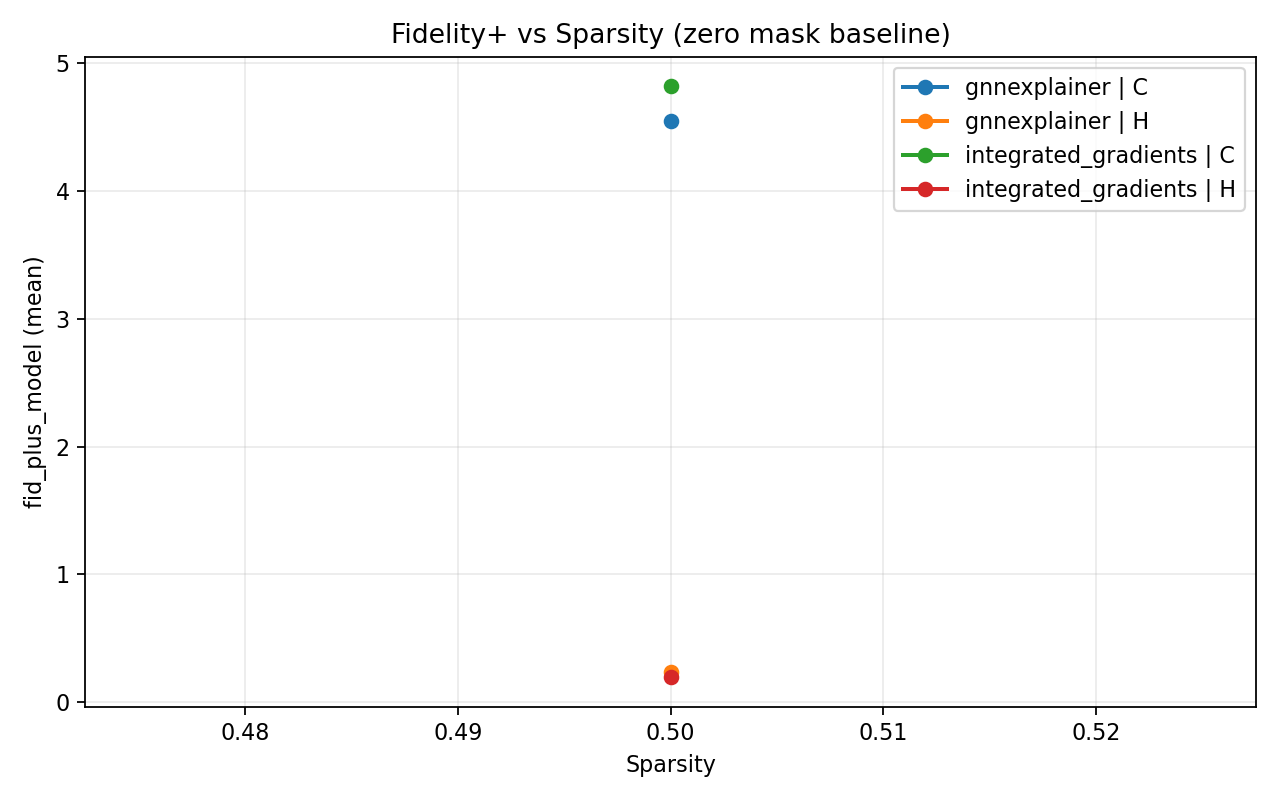

fid_minus_zero: c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\experiments\fidelity_grid_smoke_20260308_211230\plots\fid_minus_zero.png


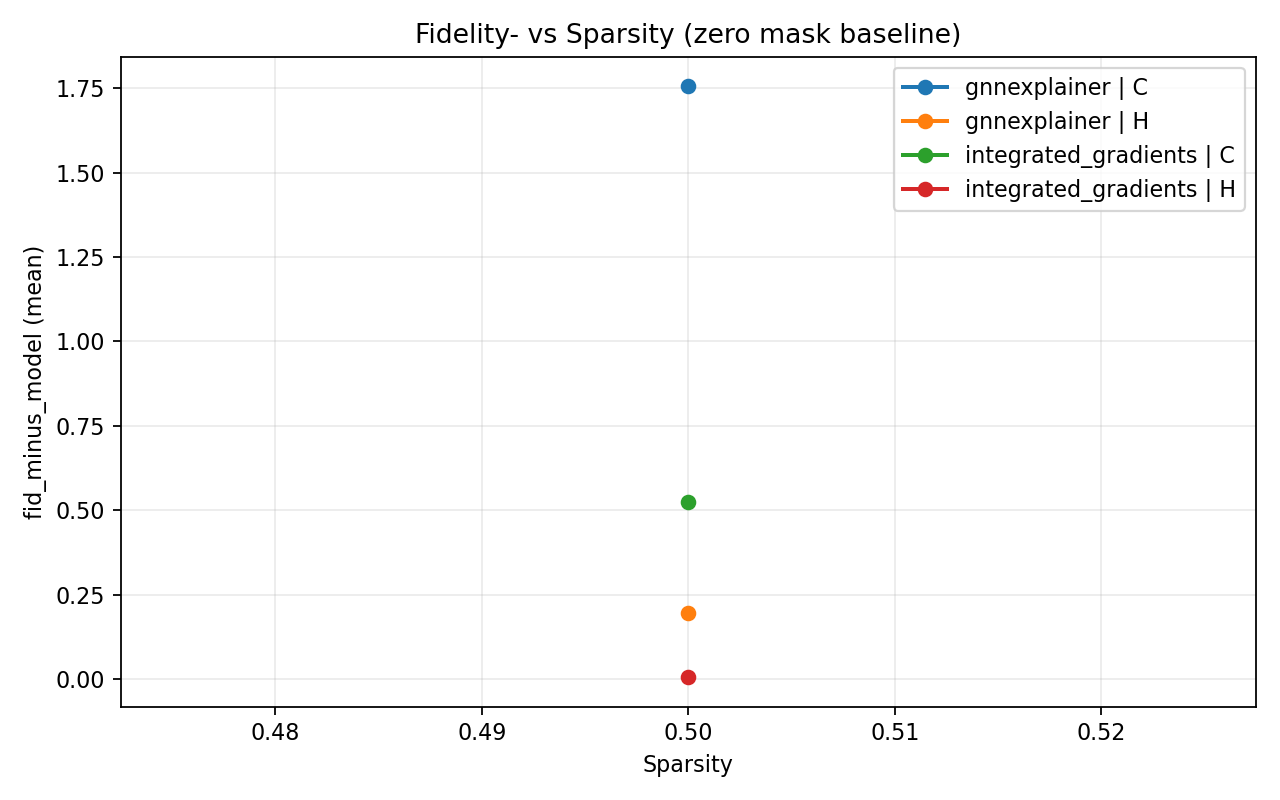

fid_plus_scientific: c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\experiments\fidelity_grid_smoke_20260308_211230\plots\fid_plus_scientific.png


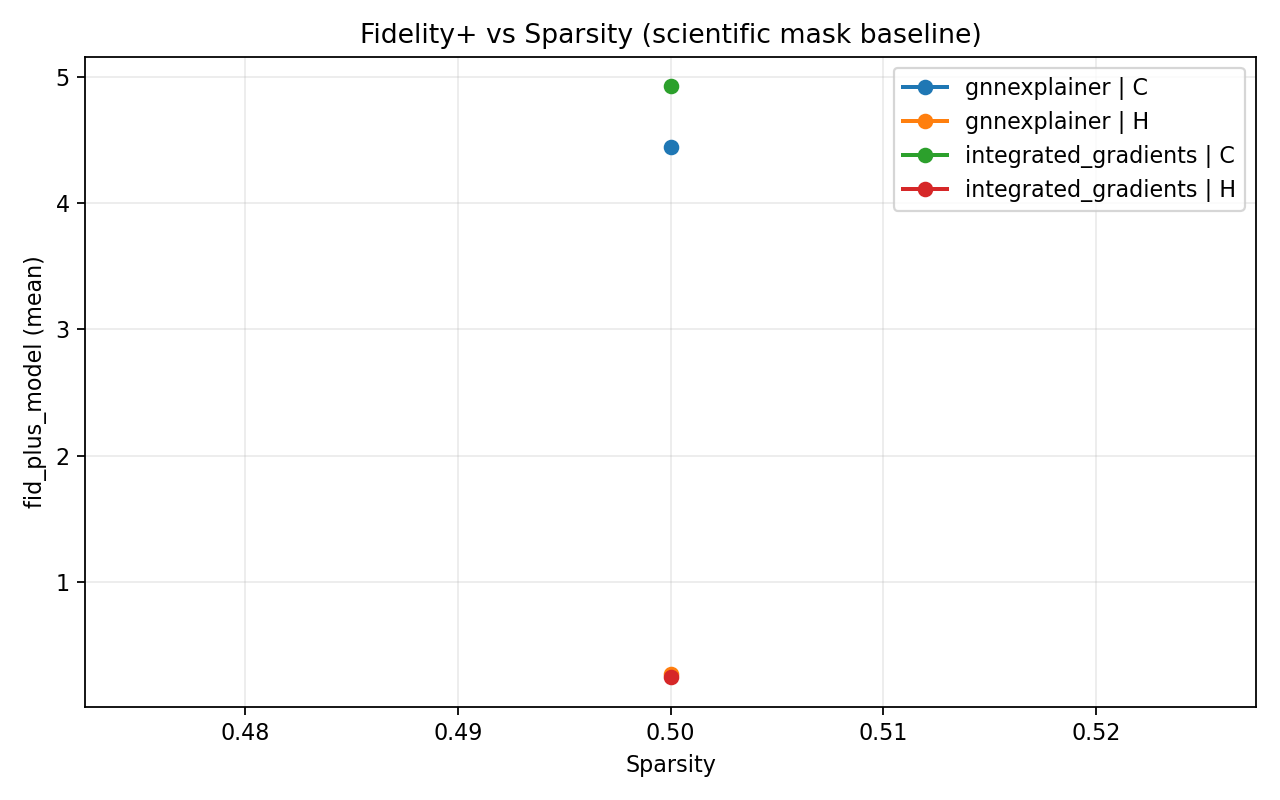

fid_minus_scientific: c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\experiments\fidelity_grid_smoke_20260308_211230\plots\fid_minus_scientific.png


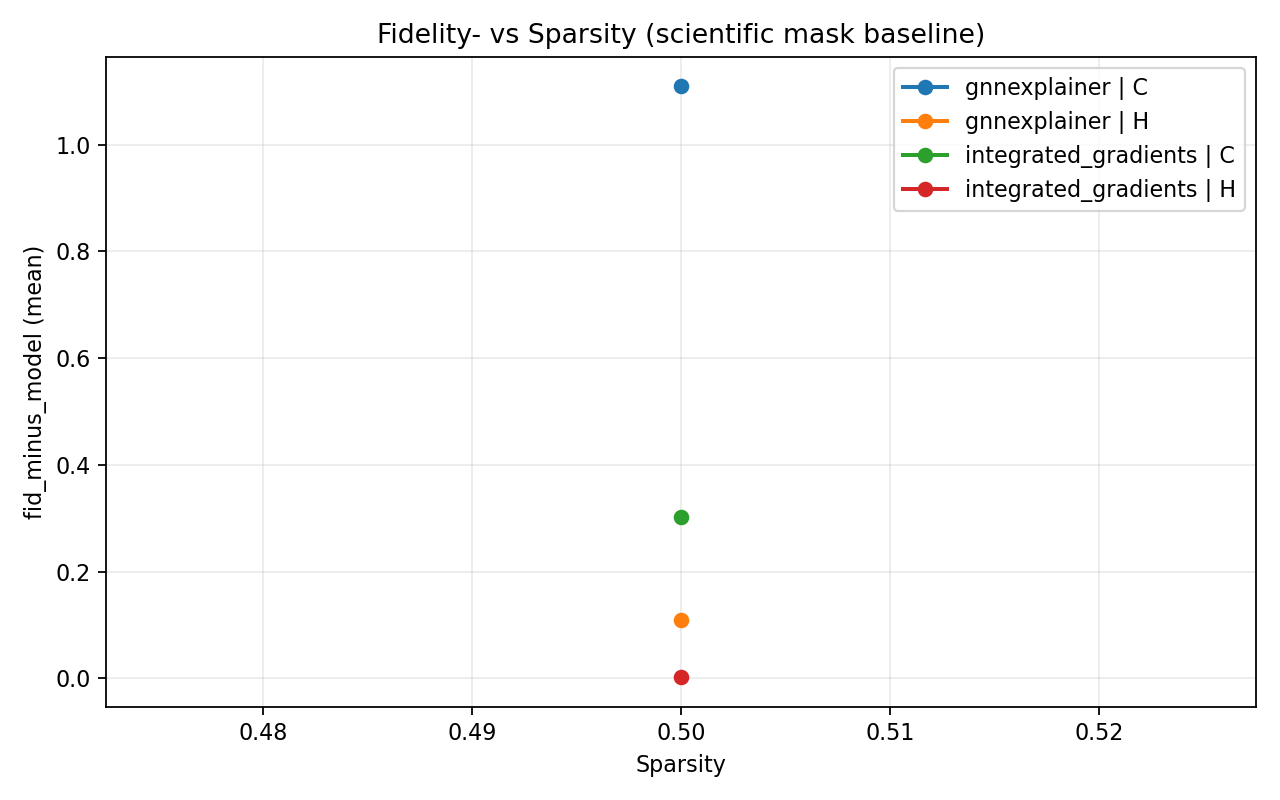

gnn_edge_fid_plus_zero: c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\experiments\fidelity_grid_smoke_20260308_211230\plots\gnn_edge_fid_plus_zero.png


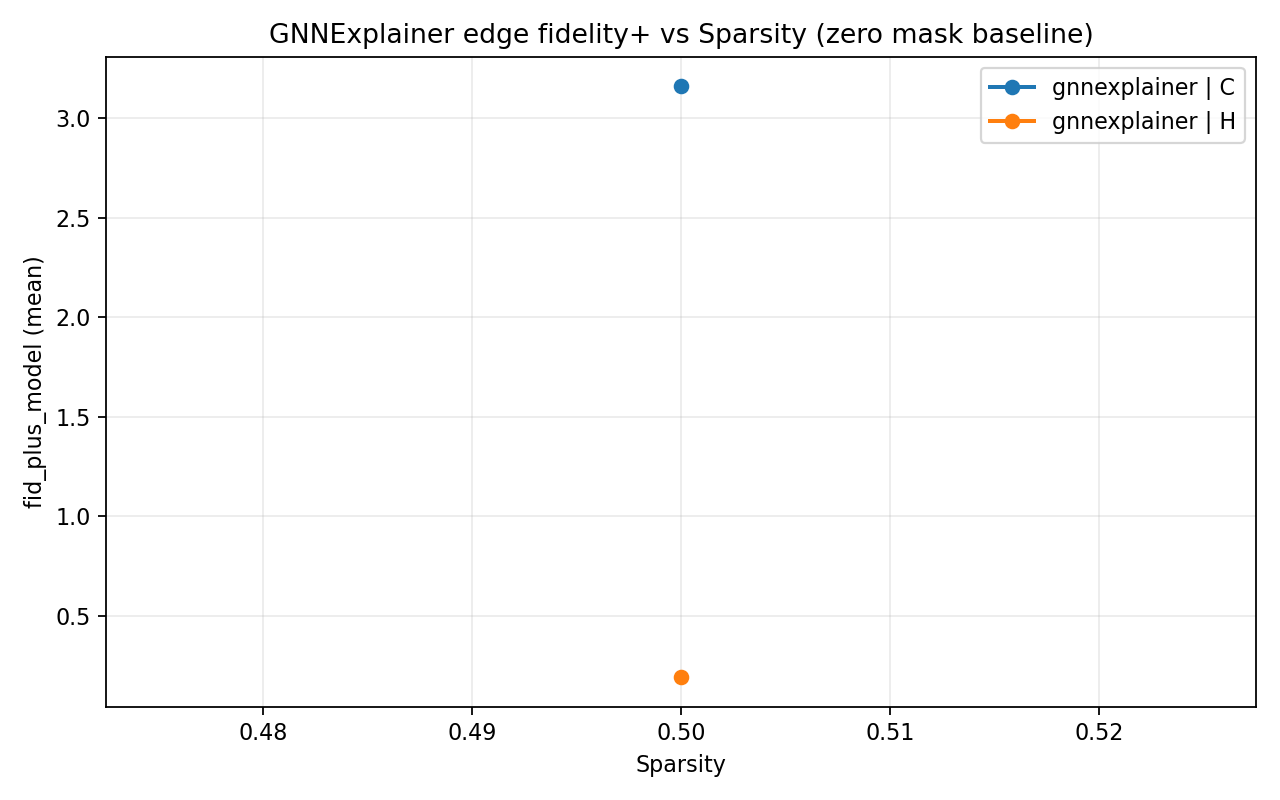

gnn_edge_fid_minus_zero: c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\experiments\fidelity_grid_smoke_20260308_211230\plots\gnn_edge_fid_minus_zero.png


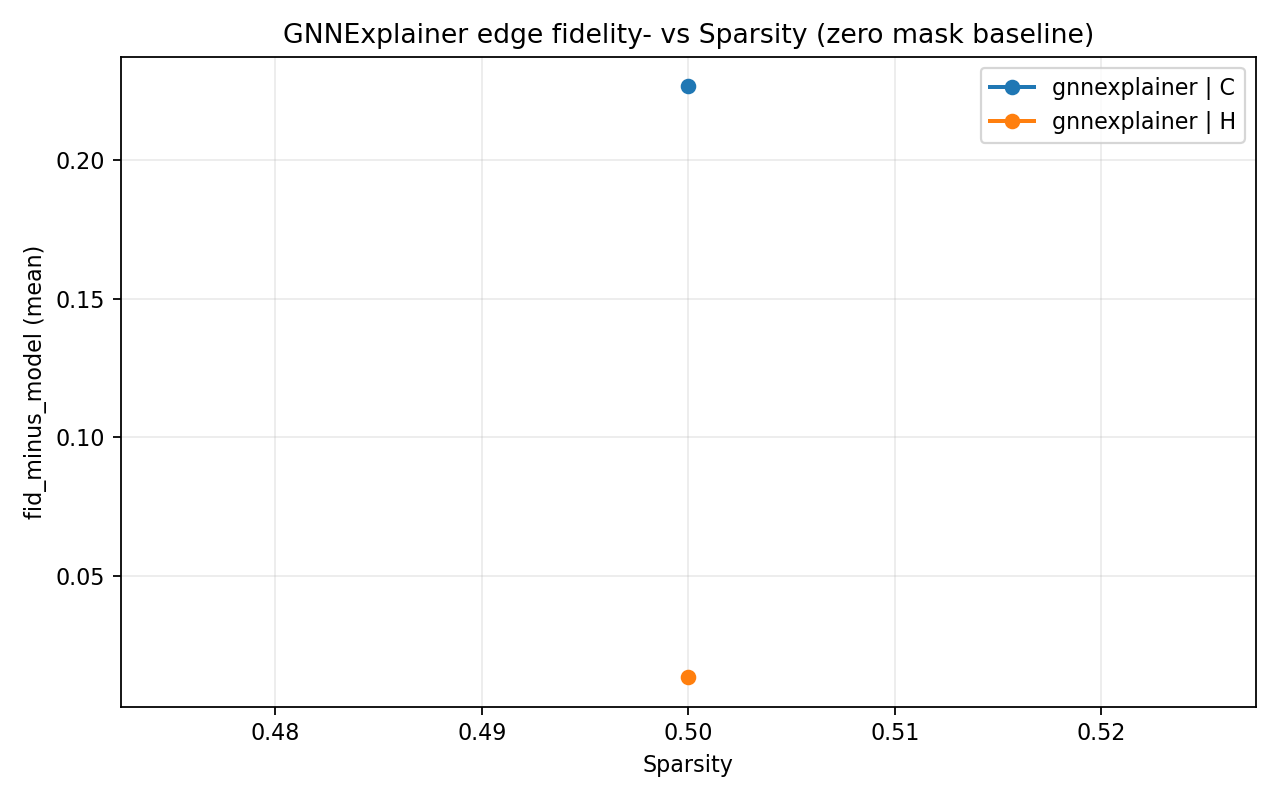

gnn_edge_fid_plus_scientific: c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\experiments\fidelity_grid_smoke_20260308_211230\plots\gnn_edge_fid_plus_scientific.png


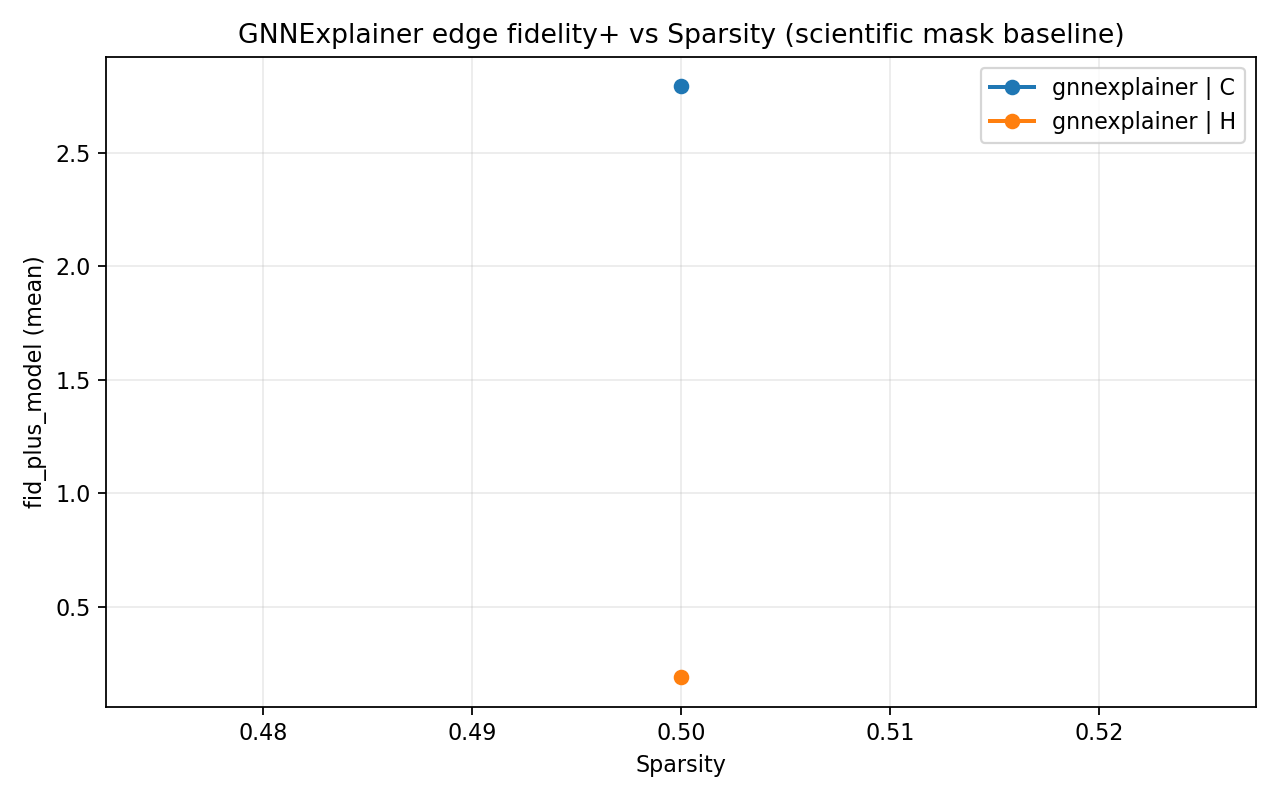

gnn_edge_fid_minus_scientific: c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\experiments\fidelity_grid_smoke_20260308_211230\plots\gnn_edge_fid_minus_scientific.png


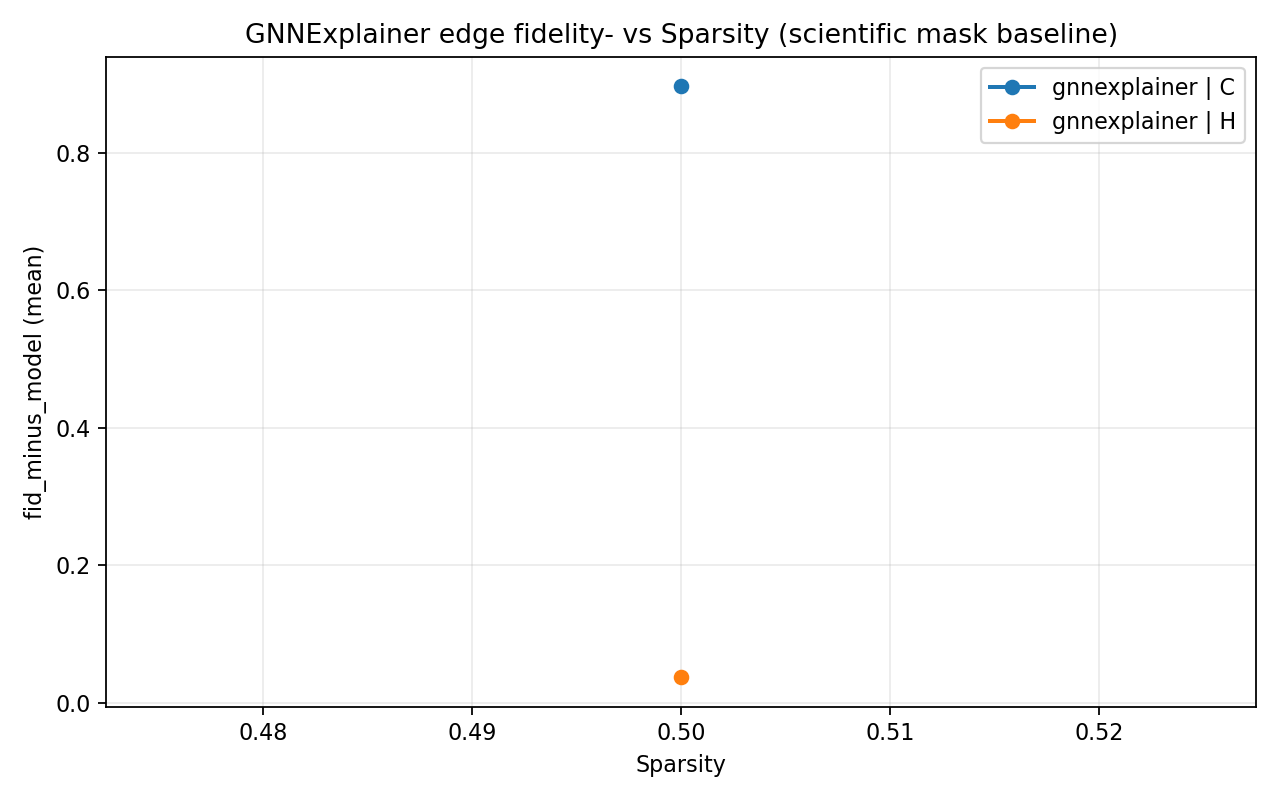

In [6]:
# Minimaler Grid-Smoke-Test (1 Sparsity x 2 Masken)
from IPython.display import Image, display

smoke_result = run_fidelity_grid_smoke_test(
    node_types=('H', 'C'),
    gnn_epochs=int(gnn_epochs_widget.value),
    gnn_lr=float(gnn_lr_widget.value),
    gnn_explanation_type='phenomenon',
    ig_n_steps=int(ig_n_steps_widget.value),
    output_dir=output_dir_widget.value,
    seed=int(seed_widget.value),
    verbose=True,
)

print('Smoke run directory:', smoke_result['run_dir'])
print('Smoke manifest:', smoke_result['manifest_path'])
display(smoke_result['run_status_df'])
display(smoke_result['summary_df'])

smoke_plot_order = []
for node_type in ('H', 'C'):
    smoke_plot_order.extend([
        f'fid_plus_zero_{node_type}',
        f'fid_minus_zero_{node_type}',
        f'fid_plus_scientific_{node_type}',
        f'fid_minus_scientific_{node_type}',
        f'gnn_edge_fid_plus_zero_{node_type}',
        f'gnn_edge_fid_minus_zero_{node_type}',
        f'gnn_edge_fid_plus_scientific_{node_type}',
        f'gnn_edge_fid_minus_scientific_{node_type}',
    ])
for key in smoke_plot_order:
    path = smoke_result['plot_paths'].get(key)
    print(f'{key}: {path}')
    if path:
        display(Image(filename=path))
